# Lab Segmentation 1

In [1]:
from commonfunctions import *
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.color import rgb2gray

In [ ]:
## For all requirements: The quality of the results is evaluated.


# 1- Read the image 
# [VERY IMPORTANT] and convert it to float: image = image.astype(float)

# read image golf



# 2- Retreive the 3 channels of the image(R,G,B) (will be used in the coming steps)


# 3- Visually (not by code) detect the dominating color channel (C) for the backgroung (R, G or B)

# 4- Draw the dominating channel (r, g or b) thresholded by some threshold (to make sure your choice is meaningful)


# 5- Get an intuitive way(There is a very simple way) to make a mask that can get the pixels where the values of the dominating channels 
# have larger values than the other channels with an appropriate threshold

# 6- display the binarized image






In [21]:
def extract_foreground_from_dominant_channel(img_path, threshold=0.05):
    # 1
    img = imread(img_path).astype(float) / 255.0  
    # 2
    R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]
    # 3
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(R, cmap='Reds')
    ax[0].set_title('Red Channel')
    ax[1].imshow(G, cmap='Greens')
    ax[1].set_title('Green Channel')
    ax[2].imshow(B, cmap='Blues')
    ax[2].set_title('Blue Channel')
    plt.show()

    dominant = G
    # 4
    dominant_thresh = dominant > np.mean(dominant) + threshold
    plt.imshow(dominant_thresh, cmap='gray')
    plt.title("Thresholded Dominant Channel (green)")
    plt.show()
    
    # 5
    mask = (R < G - threshold) & (B < G - threshold)
    mask = ~mask
    
    # 6
    plt.imshow(mask, cmap='gray')
    plt.title("Extracted Foreground Mask")
    plt.show()
    
    return mask, img


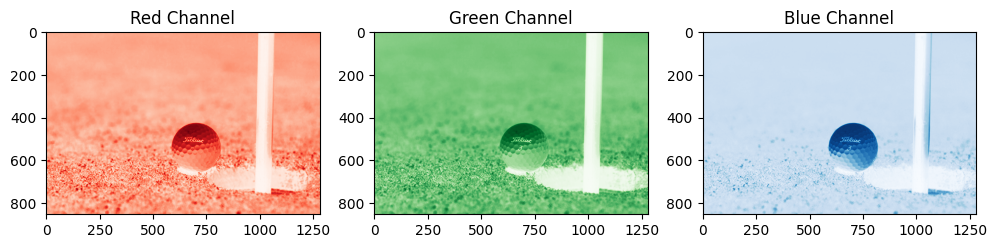

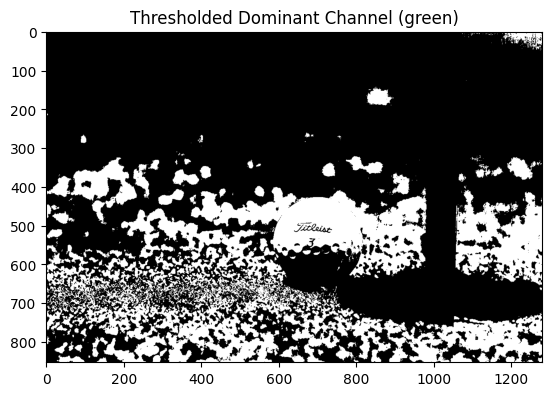

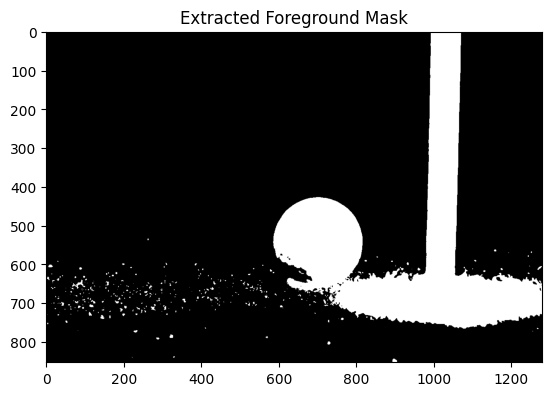

In [22]:
mask, img= extract_foreground_from_dominant_channel('imgs/exp1/golf.jpeg', threshold=0.05)

In [ ]:
# 1- Get the required RGB color (Using a color picker)


# 2- Read image

# 3- extract R, G and B channels (as float)

# 4- calculate differences FOR EACH CHANNEL (between the image and the required pixel value)

# 5- calculate overall distance from the given RGB color (use any appropriate distance measure, take care of the minus distances)

# 6-  create a mask by thresholding the differences

# 7- In the input image, Replace the pixels of the mask with the following color
# R = 230 , G = 90 , B=40

# 8- show the image or save it


In [27]:
def replace_similar_color(
    img_path,
    target_color=(86, 100, 40),
    new_color=(230, 90, 40),
    threshold=60
):

    # 1 , 2
    img = imread(img_path).astype(float)
    R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]

    # 3
    target = np.array(target_color, dtype=float)

    # 4 , 5
    diff_R = R - target[0]
    diff_G = G - target[1]
    diff_B = B - target[2]
    distance = np.sqrt(diff_R**2 + diff_G**2 + diff_B**2)

    # 6
    mask = (distance < threshold) & (G > R + 10) & (G > B + 10)

    # 7
    modified_img = img.copy()
    modified_img[mask] = np.array(new_color, dtype=float)

    img_disp = img / 255.0
    modified_disp = modified_img / 255.0

    # 8
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(img_disp)
    ax[0].set_title("Original Image")
    ax[1].imshow(mask, cmap='gray')
    ax[1].set_title("Detected Grass Mask")
    ax[2].imshow(modified_disp)
    ax[2].set_title("Modified Image (Grass Recolored)")
    plt.show()

    return modified_img, mask

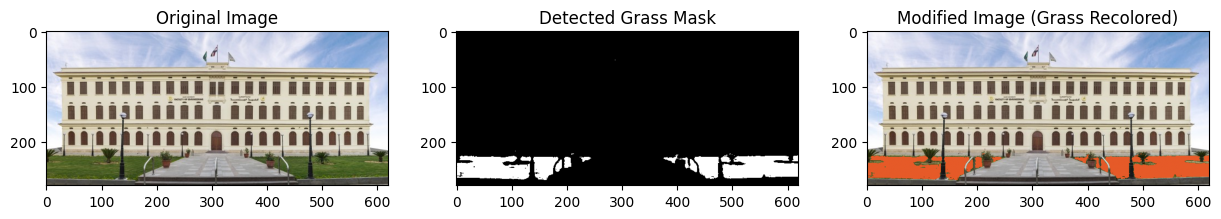

In [28]:
modified_img, mask = replace_similar_color(
    'imgs/exp2/cufe.png')